In [ ]:
# Leaf Disease Diagnosis — Real life Inference

# In this notebook , I use the model in a real life situation.
# - The pre-trained ResNet50 model is loaded and the JSON file containing the 38 different leaf disease classes.
# - The user is prompted to upload a picture of a leaf
# - The uploaded image is resized to meet the specific input requirement ( 224 x 224 pixels)
# - The model analyses this upload image and predicts the most likely health condiction of the leaf.
# - The uploaded image is displayed alongside the Top-3 predictions and their respective confidence percentages.

# Summary
# See the last cell in this notebook.


In [ ]:
import os, json
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

# ===== CONFIG =====
MODEL_PATH = "/content/gdrive/MyDrive/leaf_diagnosis_project/models/resnet_leaf_finetuned_b1.keras"
CLASS_NAMES_PATH = "/content/gdrive/MyDrive/leaf_diagnosis_project/models/leaf_class_indices_b1.json"

IMG_SIZE = (224, 224)
TOP_K = 3

Mounted at /content/gdrive


In [ ]:
# Load Model and  Class Names

# Load model
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded:", MODEL_PATH)

# Load class names
with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

print("Classes loaded:", len(class_names))

Model loaded: /content/gdrive/MyDrive/leaf_diagnosis_project/models/resnet_leaf_finetuned.keras
Classes loaded: 38


In [ ]:
# Core Preprocess + Predict Functions

def prepare_image(img_path, img_size=IMG_SIZE):
    """Load an image file and preprocess it for ResNet50."""
    img = image.load_img(img_path, target_size=img_size)
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr, img

def predict_leaf(img_path, top_k=TOP_K, show=True):
    """Predict disease class for a single leaf image."""
    x, display_img = prepare_image(img_path)
    probs = model.predict(x, verbose=0)[0]

    top_idx = np.argsort(probs)[-top_k:][::-1]
    results = [(class_names[i], float(probs[i])) for i in top_idx]

    if show:
        plt.figure(figsize=(5,5))
        plt.imshow(display_img)
        plt.axis("off")
        title = f"Top-1: {results[0][0]} ({results[0][1]*100:.2f}%)"
        plt.title(title)
        plt.show()

        print("Top predictions:")
        for name, p in results:
            print(f"  {name}: {p*100:.2f}%")

    return results

In [ ]:
# Asing user to upload a picture of a leaf from his device.

from google.colab import files
uploaded = files.upload()

# Get the first uploaded filename
img_path = "/content/" + next(iter(uploaded))
print("Uploaded:", img_path)

Saving PLPATH-FRU-35-Strawberry-Leaf-Diseases-figure-3_scorch.jpg to PLPATH-FRU-35-Strawberry-Leaf-Diseases-figure-3_scorch.jpg
Uploaded: /content/PLPATH-FRU-35-Strawberry-Leaf-Diseases-figure-3_scorch.jpg


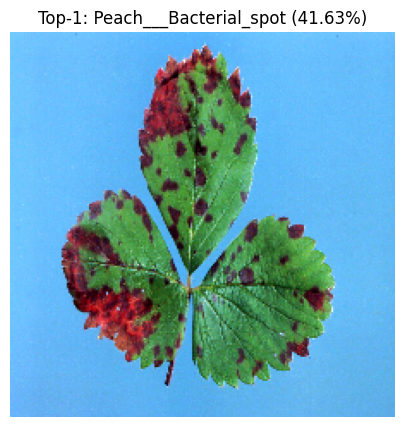

Top predictions:
  Peach___Bacterial_spot: 41.63%
  Strawberry___Leaf_scorch: 29.41%
  Apple___Black_rot: 25.46%


In [ ]:
# Predicting top 3 conditions
_ = predict_leaf(img_path, top_k=3, show=True)

In [ ]:
# Summary

# The trained model achieved high accuracy when evaluated on images that closely
# matched the characteristics of the training dataset. These images were captured
# under controlled conditions, featuring uniform backgrounds and consistent studio
# lighting, which reduced visual variability and enabled the model to effectively
# learn distinguishing features related to leaf health.

# However, when the model was tested on real-world images captured using a camera
# in natural environments, its performance degraded noticeably. These images
# introduced significant variability, including non-uniform and cluttered backgrounds,
# inconsistent natural lighting, shadows, varying angles, and differences in image quality.
# Since such conditions were not adequately represented in the training data, the
# model struggled to generalize beyond the controlled setting.

# This performance gap illustrates the impact of domain shift, where discrepancies
# between training and deployment data distributions lead to reduced model
# robustness in real-world scenarios.